In [96]:
import vtk
import matplotlib.pyplot as plt
import numpy as np
import os
from vtk import vtkXMLUnstructuredGridReader
from vtk.util.numpy_support import vtk_to_numpy

import matplotlib.patches as patches
from scipy.spatial import KDTree
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe

import pygmt

In [127]:
base_model_path = "/Users/danieldouglas/software/aspect/build/"
dryp_path = base_model_path + "dry_test/solution/"
wetp_path = base_model_path + "wet_test/solution/"

dry_path = base_model_path + "dry_test_no_Peierls/solution/"
wet_path = base_model_path + "wet_test_no_Peierls/solution/"

dryp_solutions = np.sort(os.listdir( dryp_path ))
wetp_solutions = np.sort(os.listdir( wetp_path ))
dry_solutions = np.sort(os.listdir( dry_path ))
wet_solutions = np.sort(os.listdir( wet_path ))

path_array = np.array([dry_path, wet_path, dryp_path, wetp_path])
solutions_array = np.array([dry_solutions, wet_solutions, dryp_solutions, wetp_solutions], dtype=object)

t_step = 0

T = np.empty(0)
p = np.empty(0)
wetp_visc = np.empty(0)
dryp_visc = np.empty(0)
wet_visc = np.empty(0)
dry_visc = np.empty(0)

for i in range(len(path_array)):
    for soln in solutions_array[i]:
        if soln[-4:-1] == '.vt' and soln[9:14] == str(t_step).zfill(5):

            file_path = os.path.join(path_array[i], soln)
            reader = vtkXMLUnstructuredGridReader()
            reader.SetFileName(file_path)
            reader.Update()
            data = reader.GetOutput()
            points = data.GetPoints()
            x = vtk_to_numpy(points.GetData())
            T = vtk_to_numpy(data.GetPointData().GetArray('T'))
            p = vtk_to_numpy(data.GetPointData().GetArray('p'))
            if i == 0:
                dry_visc = vtk_to_numpy(data.GetPointData().GetArray('viscosity'))
            elif i == 1:
                wet_visc = vtk_to_numpy(data.GetPointData().GetArray('viscosity'))
            elif i == 2:
                dryp_visc = vtk_to_numpy(data.GetPointData().GetArray('viscosity'))
            elif i == 3:
                wetp_visc = vtk_to_numpy(data.GetPointData().GetArray('viscosity'))

In [128]:
np.min(dry_visc)

3.6885176e+23

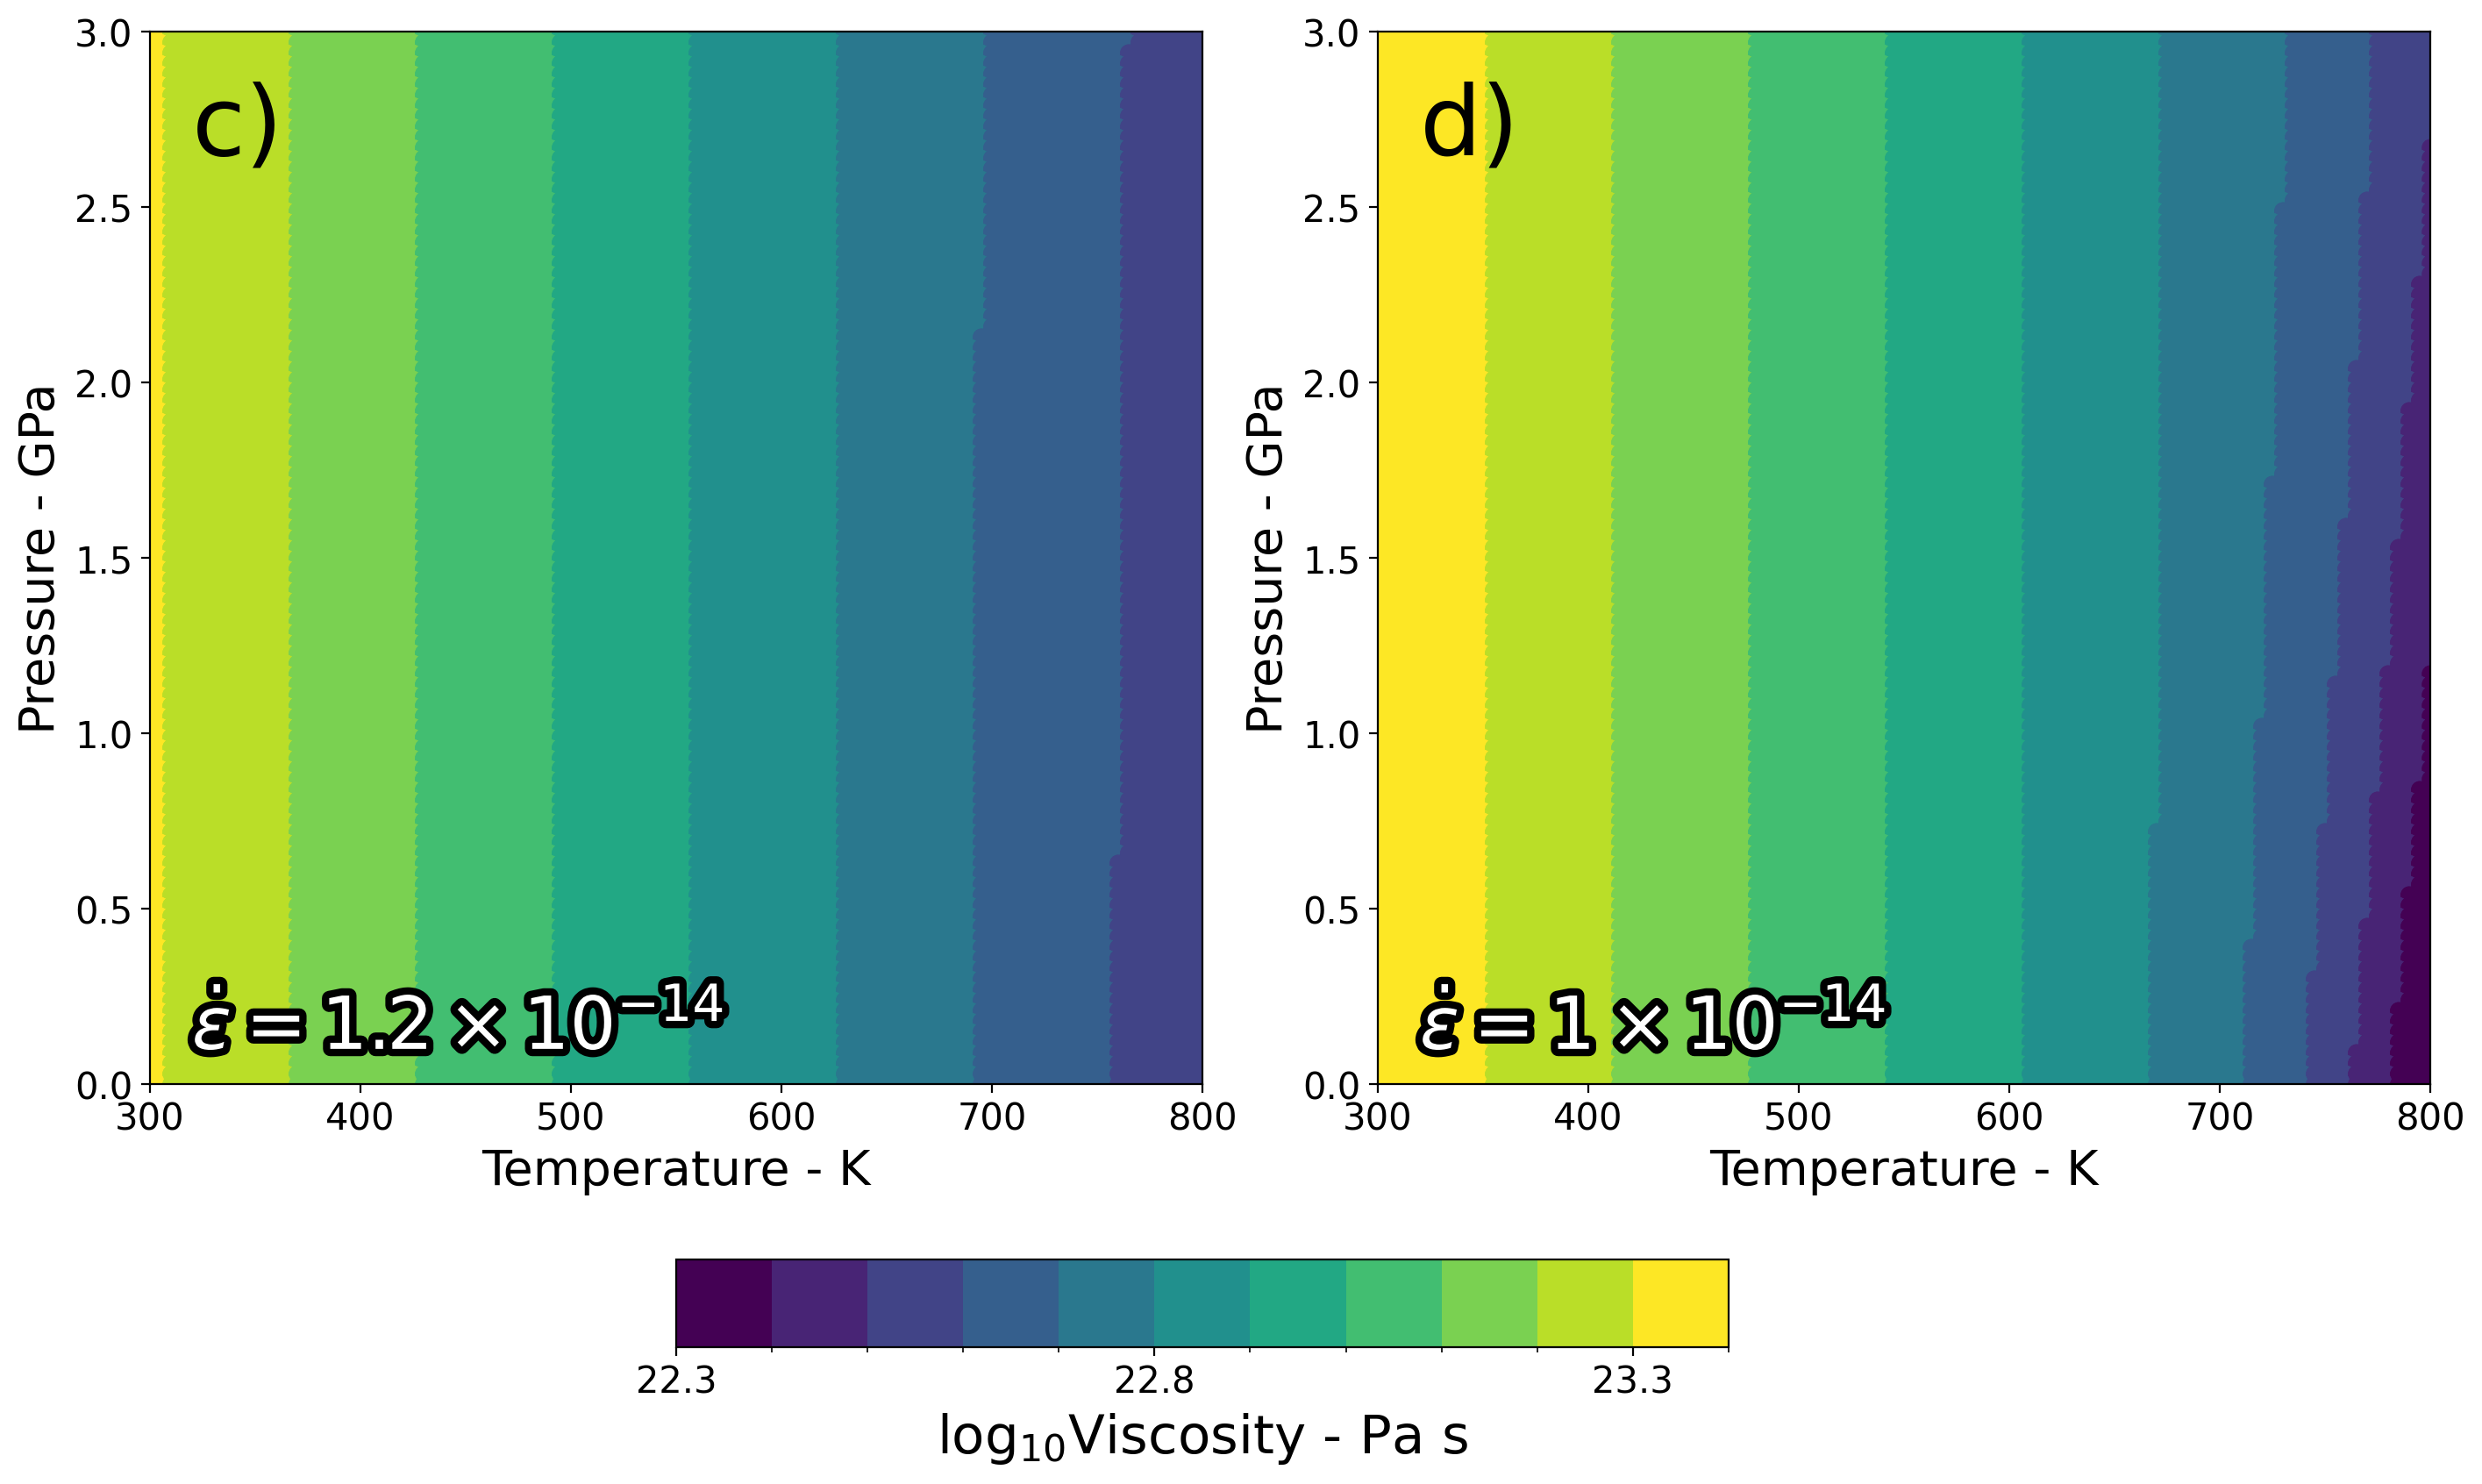

In [129]:
ymin, ymax = 0, 3
xmin, xmax = 300, 800

axes_width, axes_height  = 6, 6
spacing = 1
cbar_width, cbar_spacing = 0.5, 0.5

fig_size_x = 2*axes_width + spacing
fig_size_y = 2*axes_height + spacing

fig = plt.figure(dpi=200, figsize=(fig_size_x, fig_size_y))

dry_box = [0, 0, 
           axes_width / fig_size_x, axes_height / fig_size_y]
wet_box = [(axes_width + spacing) / fig_size_x, 0, 
            axes_width / fig_size_x, axes_height / fig_size_y]

cbar_axes = fig.add_axes([axes_width/fig_size_x/2, -3/2*spacing/fig_size_y, 
                          axes_width/fig_size_x, cbar_spacing/fig_size_y])

ax_dry = fig.add_axes(dry_box)
ax_wet = fig.add_axes(wet_box)
dvisc=0.1
levels = np.arange(22.3, 23.3 + dvisc, dvisc)
tick_levels = np.array([22.3, 22.8, 23.3])

norm = mcolors.BoundaryNorm(levels, ncolors=plt.get_cmap('viridis').N, clip=True)
sc = ax_dry.scatter(T, p/1e9, c=np.log10(dryp_visc), cmap='viridis', norm=norm)
cbar = plt.colorbar(sc, orientation='horizontal', cax=cbar_axes, ticks=tick_levels)
cbar.set_label("log$_{10}$Viscosity - Pa s", fontsize=22)
cbar.ax.tick_params(labelsize=15)
sc = ax_wet.scatter(T, p/1e9, c=np.log10(wetp_visc), cmap='viridis', norm=norm)

ax_dry.set_xlim(xmin, xmax)
ax_dry.set_ylim(ymin, ymax)
ax_wet.set_xlim(xmin, xmax)
ax_wet.set_ylim(ymin, ymax)

ax_dry.set_xlabel("Temperature - K", fontsize=20)
ax_dry.set_ylabel("Pressure - GPa", fontsize=20)
ax_wet.set_xlabel("Temperature - K", fontsize=20)
ax_wet.set_ylabel("Pressure - GPa", fontsize=20)
ax_wet.tick_params(labelsize=15)
ax_dry.tick_params(labelsize=15)

ax_dry.text(320, 2.65, "c)", fontsize=40)
ax_wet.text(320, 2.65, "d)", fontsize=40)

ax_dry.text(320, 0.1, "$\\dot{\epsilon}=1.2 \\times 10^{-14}$", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_wet.text(320, 0.1, "$\\dot{\epsilon}=1 \\times 10^{-14}$", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])

plt.savefig("peierls_creep_comp.png", bbox_inches="tight")
plt.show()

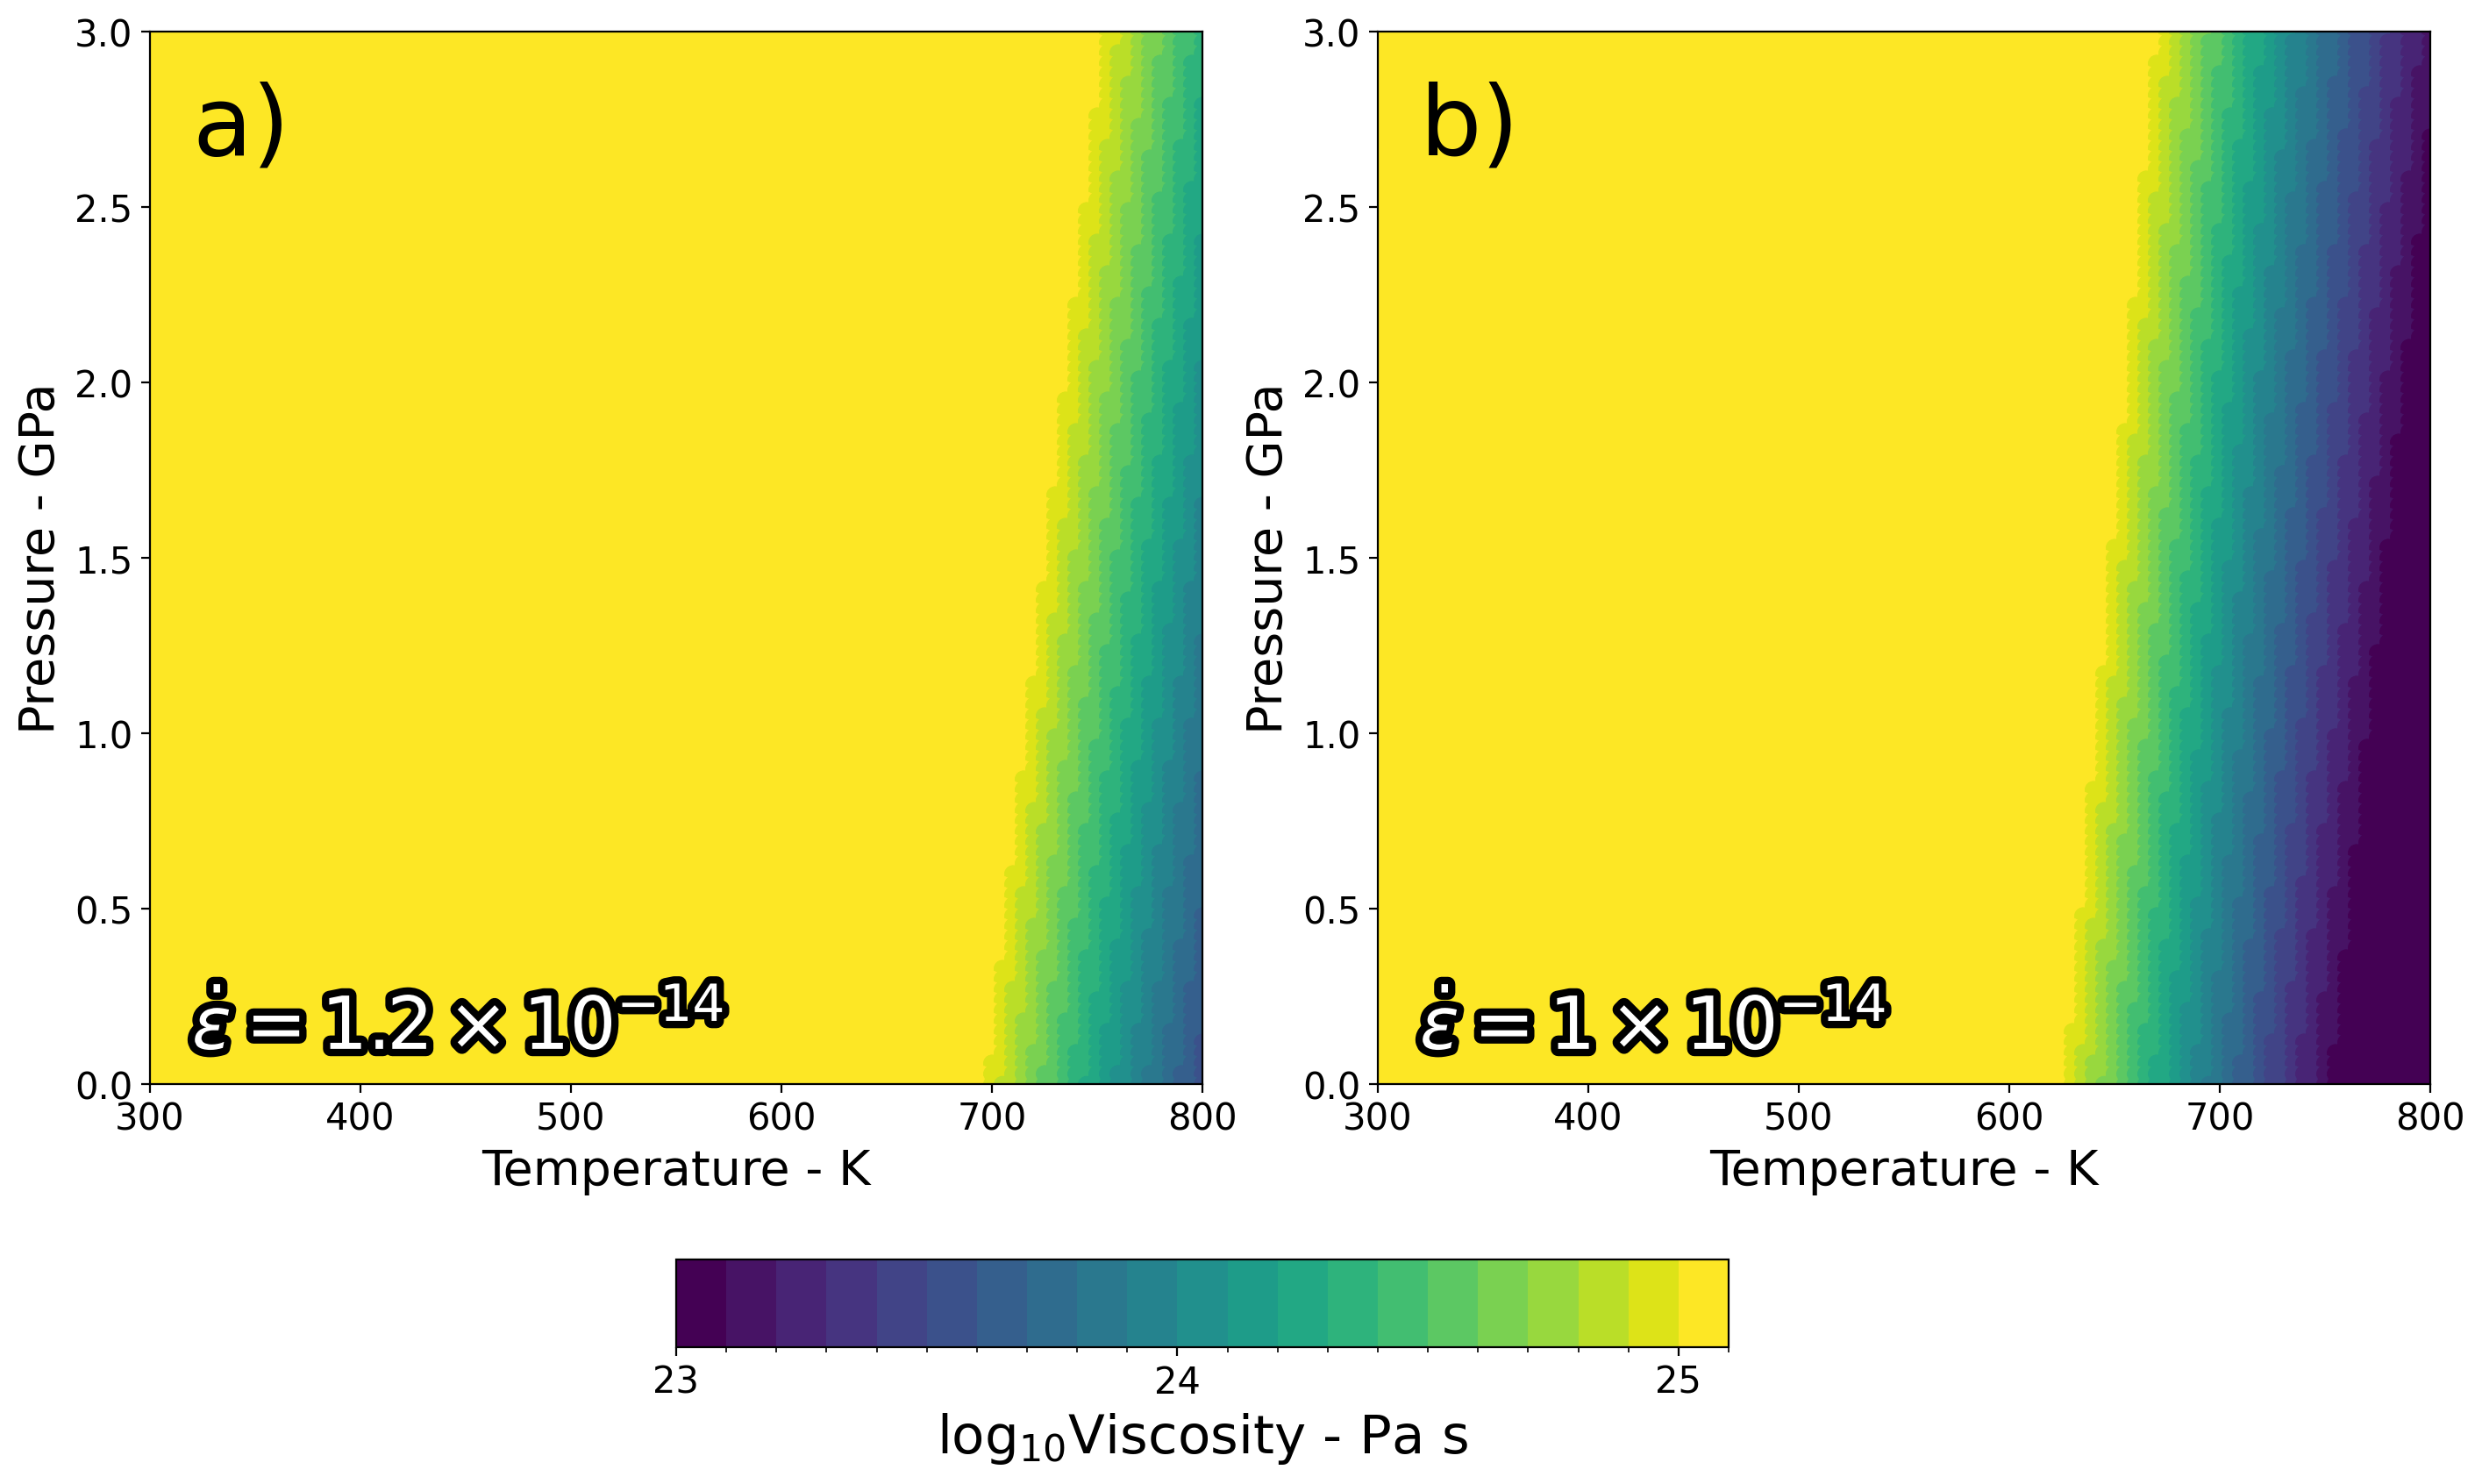

In [132]:
ymin, ymax = 0, 3
xmin, xmax = 300, 800

axes_width, axes_height  = 6, 6
spacing = 1
cbar_width, cbar_spacing = 0.5, 0.5

fig_size_x = 2*axes_width + spacing
fig_size_y = 2*axes_height + spacing

fig = plt.figure(dpi=200, figsize=(fig_size_x, fig_size_y))

dry_box = [0, 0, 
           axes_width / fig_size_x, axes_height / fig_size_y]
wet_box = [(axes_width + spacing) / fig_size_x, 0, 
            axes_width / fig_size_x, axes_height / fig_size_y]

cbar_axes = fig.add_axes([axes_width/fig_size_x/2, -3/2*spacing/fig_size_y, 
                          axes_width/fig_size_x, cbar_spacing/fig_size_y])

ax_dry = fig.add_axes(dry_box)
ax_wet = fig.add_axes(wet_box)
dvisc=0.1
levels = np.arange(23, 25 + dvisc, dvisc)
tick_levels = np.array([23, 24, 25])

norm = mcolors.BoundaryNorm(levels, ncolors=plt.get_cmap('viridis').N, clip=True)
sc = ax_dry.scatter(T, p/1e9, c=np.log10(dry_visc), cmap='viridis', norm=norm)
cbar = plt.colorbar(sc, orientation='horizontal', cax=cbar_axes, ticks=tick_levels)
cbar.set_label("log$_{10}$Viscosity - Pa s", fontsize=22)
cbar.ax.tick_params(labelsize=15)
sc = ax_wet.scatter(T, p/1e9, c=np.log10(wet_visc), cmap='viridis', norm=norm)

ax_dry.set_xlim(xmin, xmax)
ax_dry.set_ylim(ymin, ymax)
ax_wet.set_xlim(xmin, xmax)
ax_wet.set_ylim(ymin, ymax)

ax_dry.set_xlabel("Temperature - K", fontsize=20)
ax_dry.set_ylabel("Pressure - GPa", fontsize=20)
ax_wet.set_xlabel("Temperature - K", fontsize=20)
ax_wet.set_ylabel("Pressure - GPa", fontsize=20)
ax_wet.tick_params(labelsize=15)
ax_dry.tick_params(labelsize=15)

ax_dry.text(320, 2.65, "a)", fontsize=40)
ax_wet.text(320, 2.65, "b)", fontsize=40)

ax_dry.text(320, 0.1, "$\\dot{\epsilon}=1.2 \\times 10^{-14}$", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_wet.text(320, 0.1, "$\\dot{\epsilon}=1 \\times 10^{-14}$", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])

plt.savefig("no_peierls_creep_comp.png", bbox_inches="tight")
plt.show()